In [24]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna 

from mpl_toolkits.mplot3d import Axes3D


In [27]:
df = pd.read_csv('converted_voltage_thickness.csv')
print(df.head())

   Voltage(V)  Thickness(nm)      Value
0         0.0            100  21.146976
1         0.0            200  21.379830
2         0.0            300  21.507179
3         0.0            400  21.555674
4         0.0            500  21.542535


In [ ]:
import pandas as pd
import re

def createCSVFile(df, filename):
    cols = df.columns
    
    
    df = df.rename(columns={cols[0]: 'Voltage'})
    
    long_data = []
    
    
    for _, row in df.iterrows():
        voltage = row['Voltage']
        
        
        for col in df.columns[1:]:
            thickness = int(re.search(r'\d+', col).group())  
            value = row[col]
            
            long_data.append([voltage, thickness, value])
    
    
    new_df = pd.DataFrame(long_data, columns=['Voltage(V)', 'Thickness(nm)', 'Value']) 
    new_df.to_csv(filename, index=False)
    
    print("CSV file created:", 'Converted_csv_file.csv')


createCSVFile(df, 'converted_voltage_thickness.csv')

CSV file created: Converted_csv_file.csv


In [28]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Voltage(V)     240 non-null    float64
 1   Thickness(nm)  240 non-null    int64  
 2   Value          240 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 5.8 KB
None


In [29]:
print(df.isnull().sum())

Voltage(V)       0
Thickness(nm)    0
Value            0
dtype: int64


In [30]:
print(df.describe())

       Voltage(V)  Thickness(nm)       Value
count  240.000000     240.000000  240.000000
mean     0.575000     550.000000   20.090138
std      0.346833     287.828401    4.755860
min      0.000000     100.000000   -2.989954
25%      0.287500     300.000000   21.056675
50%      0.575000     550.000000   21.357715
75%      0.862500     800.000000   21.479117
max      1.150000    1000.000000   21.555674


In [31]:
X_train = df.iloc[: , :-1]
y_train = df.iloc[: , -1]


In [32]:
def create_study(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 100)
    max_depth = trial.suggest_int('max_depth', 2, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    
    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                  min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
                                  random_state=42, criterion='absolute_error')
    
    model.fit(X_train, y_train)
    
    res = model.predict(X_train)
    
    return mean_absolute_error(y_train, res)
study = optuna.create_study(direction='minimize')
study.optimize(create_study, n_trials=50)
print("Best Hyperparameters:", study.best_params)



[I 2026-03-27 13:25:27,377] A new study created in memory with name: no-name-04735faf-b675-4779-9ccb-e1f2c6e644ae


[I 2026-03-27 13:25:27,479] Trial 0 finished with value: 0.04102764031784966 and parameters: {'n_estimators': 74, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.04102764031784966.
[I 2026-03-27 13:25:27,523] Trial 1 finished with value: 0.6590539120879627 and parameters: {'n_estimators': 36, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.04102764031784966.
[I 2026-03-27 13:25:27,631] Trial 2 finished with value: 0.5879492395815584 and parameters: {'n_estimators': 94, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.04102764031784966.
[I 2026-03-27 13:25:27,667] Trial 3 finished with value: 0.8125050799655175 and parameters: {'n_estimators': 29, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.04102764031784966.
[I 2026-03-27 13:25:27,766] Trial 4 finished with value: 0.8081568508935162 and parameters: 

Best Hyperparameters: {'n_estimators': 77, 'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 1}


In [33]:

model = RandomForestRegressor(**study.best_params, random_state=42, criterion='absolute_error')
model.fit(df.iloc[: , :-1], df.iloc[: , -1])
print(f'Model Score: {model.score(df.iloc[: , :-1], df.iloc[: , -1])}')
print(f'mean_absolute_error: {mean_absolute_error(df.iloc[: , -1], model.predict(df.iloc[: , :-1]))}')
print(f'mean_squared_error: {mean_squared_error(df.iloc[: , -1], model.predict(df.iloc[: , :-1]))}')
print(f'r2_score: {r2_score(df.iloc[: , -1], model.predict(df.iloc[: , :-1]))}')

Model Score: 0.9999016908779234
mean_absolute_error: 0.013112571048972657
mean_squared_error: 0.0022143106790382472
r2_score: 0.9999016908779234


In [34]:
df2 = pd.read_csv('converted_voltage_thickness.csv')

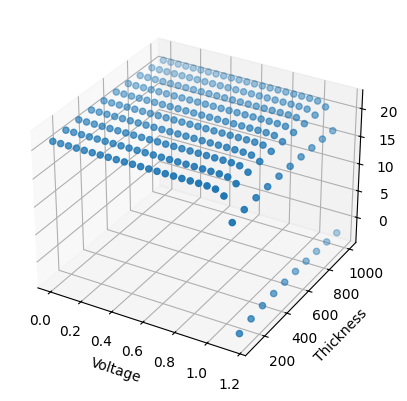

In [ ]:
#this is prediction for the same data 
x0_input = df['Voltage(V)'].to_numpy()
x1_input = df['Thickness(nm)'].to_numpy()
y_input = df['Value'].to_numpy()


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x0_input, x1_input, y_input)

ax.set_xlabel('Voltage')
ax.set_ylabel('Thickness')
ax.set_zlabel('Output')

plt.show()

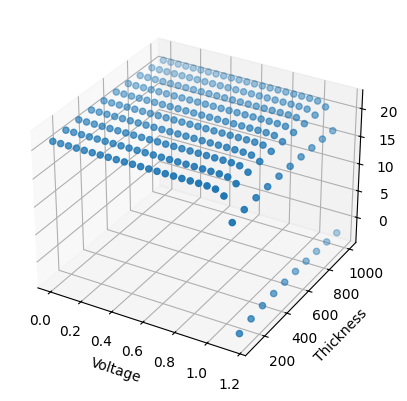

In [36]:
#this is input for the model 
x0_input = df['Voltage(V)'].to_numpy()
x1_input = df['Thickness(nm)'].to_numpy()
y = df['Value'].to_numpy()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x0_input, x1_input, y_input)

ax.set_xlabel('Voltage')
ax.set_ylabel('Thickness')
ax.set_zlabel('Output')

plt.show()
